# Environment Setup

This section sets a random seed for reproducibility and checks for GPU availability.

In [1]:
SEED = 158

In [2]:
import tensorflow as tf

# Get the GPU device name.
device_name = tf.test.gpu_device_name()

# The device name should look like the following:
if device_name == '/device:GPU:0':
    print('Found GPU at: {}'.format(device_name))
else:
    raise SystemError('GPU device not found')

2026-05-24 15:50:57.927712: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779637858.124370      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779637858.186371      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779637858.699924      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779637858.699970      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779637858.699974      23 computation_placer.cc:177] computation placer alr

Found GPU at: /device:GPU:0


I0000 00:00:1779637887.334726      23 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779637887.342211      23 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
import torch

# If there's a GPU available...
if torch.cuda.is_available():

    # Tell PyTorch to use the GPU.
    device = torch.device("cuda")

    print('There are %d GPU(s) available.' % torch.cuda.device_count())

    print('We will use the GPU:', torch.cuda.get_device_name(0))

# If not...
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 2 GPU(s) available.
We will use the GPU: Tesla T4


Install the transformers package from Hugging face and upgrade it in order to use the newer version.

In [4]:
!pip install -q -U "transformers @ git+https://github.com/huggingface/transformers.git"
!pip install --upgrade transformers

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 99.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.8.0.dev0
    Uninstalling transformers-5.8.0.dev0:
      Successfully uninstalled transformers-5.8.0.dev0


# Data Set

We load the data, save the first as an example for the prompt making later on and save the name of every model to use in the for loop later.

In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
import time
import pandas as pd

MODELS = ["Qwen/Qwen3.5-0.8B", "Qwen/Qwen3.5-2B", "Qwen/Qwen3.5-4B"] # Every model by name

dataset = load_dataset("ailsntua/QEvasion")
train = pd.DataFrame(dataset['train'])
test = pd.DataFrame(dataset['test'])

examples = train.groupby('clarity_label').sample(1, random_state=SEED) # Example to use later for prompts

README.md:   0%|          | 0.00/12.7k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

# Prompt Creation

This section creates the prompt, depending on the model strategy passed  through the variable. 

In [6]:
def get_system_prompt(strategy="zero-shot"):
    system_promt = """You are a political response classifier.
Given a question and its corresponding answer, classify the answer into one of the following categories:
- Clear Reply
- Ambivalent
- Clear Non-Reply"""
    if strategy == "cot":
        return system_promt + " Think step-by-step before providing the final label."
    return system_promt + " Respond with the label only."

def build_user_prompt(example, strategy="zero-shot"):
    few_shot_context = ""
    if strategy == "few-shot":
        for _, row in examples.iterrows():
            few_shot_context += f"""Question: {row['question']}
            Answer: {row['interview_answer']}
            Label: {row['clarity_label']}\n"""

    if strategy == "cot":
    # Took an example directly from the database
        cot_example = (
            "Question: Mr. President, one more on the Russia/U.S. Security Assistance to Ukraine. How do you respond to the Kremlin calling this a colossal risk, Mr. President?\n"
            "Answer: It is for them.\n"
            "Thought: The answer provided by the President does not directly respond to the question about how he responds to the Kremlin's characterization of the security assistance to Ukraine as a colossal risk. Instead, the President simply says, \"It is for them,\" which can be interpreted as completely avoiding the question and not offering any specific response or reaction to the Kremlin's statement. \n"
            "Label: Ambivalent\n\n"
        )
        return f"""{cot_example}Question: {example['question']}
        Answer: {example['interview_answer']}
        Thought:"""

    return f"""{few_shot_context}Question: {example['question']}
    Answer: {example['interview_answer']}
    Label:"""

# Inference and Label Extraction

The `inference` function prepares the input by applying the appropriate template (System + User prompt), processes the data in batches for efficiency with the use of GPUs, and extracts the predicted label from the model's generated text.

In [7]:
LABELS = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]

def inference(model, tokenizer, data, strategy, batch_size=4):
    prompts = []
    for _, row in data.iterrows():
        messages = [
            {"role": "system", "content": get_system_prompt(strategy)},
            {"role": "user", "content": build_user_prompt(row, strategy)}
        ]
        prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))

    results = []
    for i in range(0, len(prompts), batch_size):
        batch = prompts[i:i + batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=2048).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=100 if (strategy == "cot") else 50, # Increase the max tokens when the model is expected to output an explanation
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

        for j in range(len(batch)):
            full_text = tokenizer.decode(outputs[j][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

            prediction = "Ambivalent" # Declare it so that the errors are avoided
            for label in LABELS:
                if label.lower() in full_text.lower():
                    prediction = label
                    break
            results.append(prediction)
    return results

# Model Evaluation

This section goes through the defined models and prompting strategies. It calculates the weighted and macro F1-scores and manages GPU memory by clearing the cache after each model's run.

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

all_metrics = []

for model_name in MODELS:

    print(f"\nEvaluating Model: {model_name}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
      tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.bfloat16, device_map="auto")

    for strategy in ["zero-shot", "few-shot", "cot"]:
        preds = inference(model, tokenizer, test, strategy)

        f1 = f1_score(test['clarity_label'], preds, average='weighted')
        macro_f1 = f1_score(test['clarity_label'], preds, average='macro')

        all_metrics.append({"model": model_name,"strategy": strategy,"f1": f1,"macro_f1": macro_f1,"predictions": preds})

    del model   # Delete everuthing that is not needed after so that the storage does not fill up with data form the previous model and crushes
    torch.cuda.empty_cache()


Evaluating Model: Qwen/Qwen3.5-0.8B


config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/7.76k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/76.2k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

# Visualization and Error Analysis

We visualize the performance metrics to compare how model size and prompting strategies impact accuracy. We also identify the best-performing combination and inspect specific failure cases where the model's prediction was not the correct one.

<Figure size 1000x600 with 0 Axes>

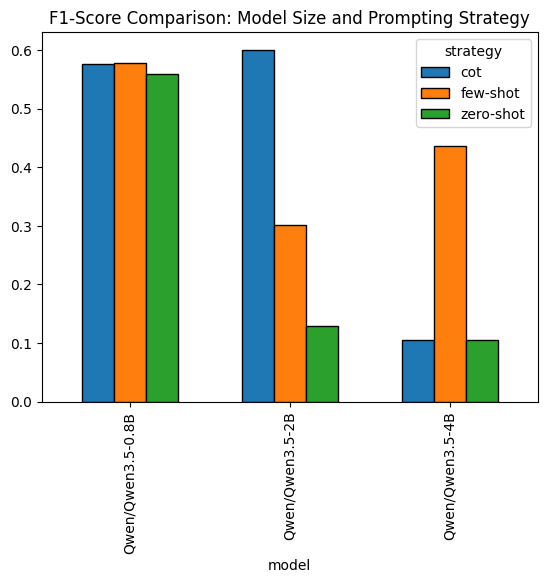


Detailed Summary Table:
               model   strategy        f1  macro_f1
0  Qwen/Qwen3.5-0.8B  zero-shot  0.559260  0.342099
1  Qwen/Qwen3.5-0.8B   few-shot  0.577932  0.426615
2  Qwen/Qwen3.5-0.8B        cot  0.576652  0.380275
3    Qwen/Qwen3.5-2B  zero-shot  0.128853  0.232243
4    Qwen/Qwen3.5-2B   few-shot  0.300742  0.300643
5    Qwen/Qwen3.5-2B        cot  0.600327  0.458760
6    Qwen/Qwen3.5-4B  zero-shot  0.104718  0.136090
7    Qwen/Qwen3.5-4B   few-shot  0.435360  0.315111
8    Qwen/Qwen3.5-4B        cot  0.104718  0.136090


In [9]:
import numpy as np
import matplotlib.pyplot as plt

results = pd.DataFrame(all_metrics)
pivot_f1 = results.pivot(index="model", columns="strategy", values="f1")

plt.figure(figsize=(10, 6))
pivot_f1.plot(kind="bar", edgecolor="black", width=0.6)
plt.title("F1-Score Comparison: Model Size and Prompting Strategy")
plt.show()

print("\nDetailed Summary Table:")
print(results[["model", "strategy", "f1", "macro_f1"]])

CLASS PERFORMANCE COMPARISON


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

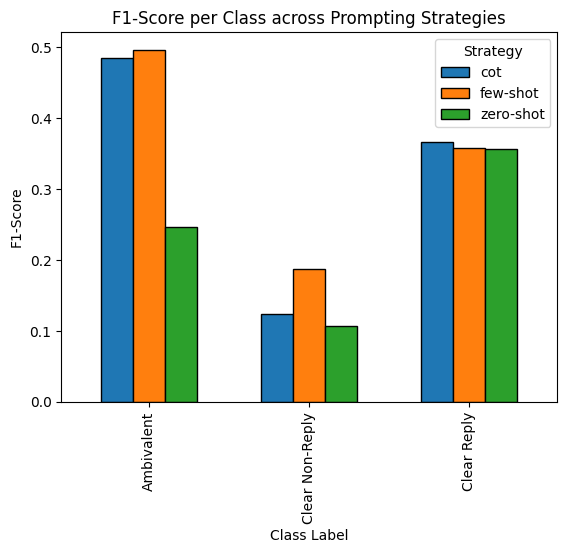


INCORRECT EXAMPLES

LABEL: Clear Non-Reply | PREDICTION: Clear Reply
Question: Closing Guantanamo Bay
Answer: Thank you for the question on a court ruling that literally came out in the midst of my meeting with the Prime Minister—and so I haven't had a chance to fully review the findings of the Supreme Court. I, one, assure you that we take them very seriously; two, that to the extent that there is latitude to work with the Congress to determine whether or not the military tribunals will be an avenue in which to give people their day in court, we will do so.The American people need to know that this ruling, as I understand it, won't cause killers to be put out on the street. In other words, there's not a—it was a drive-by briefing on the way here; I was told that this was not going to be the case. At any rate, we will seriously look at the findings, obviously. And one thing I'm not going to do, though, is I'm not going to jeopardize the safety of the American people. People have got t

In [10]:
print("CLASS PERFORMANCE COMPARISON")
compare = []
for run in all_metrics:
    report = classification_report(test['clarity_label'], run['predictions'], output_dict=True)
    for label in LABELS:
        compare.append({"Model": run['model'].split('/')[-1],"Strategy": run['strategy'],"Label": label,"F1-Score": report[label]['f1-score']})
    
comp_df = pd.DataFrame(compare)
pivot_df = comp_df.groupby(['Label', 'Strategy'])['F1-Score'].mean().unstack()
ax = pivot_df.plot(kind='bar', edgecolor="black", width=0.6)
plt.title("F1-Score per Class across Prompting Strategies")
plt.ylabel("F1-Score")
plt.xlabel("Class Label")
plt.legend(title="Strategy")
plt.show()

print("\nINCORRECT EXAMPLES")
test['cot_pred'] = next(m['predictions'] for m in all_metrics if m['model'] == model_name and m['strategy'] == 'cot')

common_errors = test[test['clarity_label'] != test['cot_pred']].sample(3)  #In case every model failed
for _, row in common_errors.iterrows():
    print(f"\nLABEL: {row['clarity_label']} | PREDICTION: {row['cot_pred']}")
    print(f"Question: {row['question']}")
    print(f"Answer: {row['interview_answer']}...")

# Submition

We create the two submission files needed (one with the name the assignment specified and one with the name for the kaggle competition)

In [11]:
best_run_index = results['f1'].idxmax()
best_predictions = results.loc[best_run_index, 'predictions']

submission = pd.DataFrame({
    "Id": test.index,
    "Predicted": best_predictions
})
submission.to_csv("submission_best_prompting_system.csv", index=False)
submission.to_csv("submission.csv", index=False)
print("Submission completed.")
print('\nFirst 10 rows:')
print(submission.head(20))

Submission completed.

First 10 rows:
    Id    Predicted
0    0   Ambivalent
1    1   Ambivalent
2    2   Ambivalent
3    3   Ambivalent
4    4   Ambivalent
5    5   Ambivalent
6    6   Ambivalent
7    7   Ambivalent
8    8   Ambivalent
9    9   Ambivalent
10  10   Ambivalent
11  11  Clear Reply
12  12   Ambivalent
13  13   Ambivalent
14  14   Ambivalent
15  15  Clear Reply
16  16   Ambivalent
17  17   Ambivalent
18  18   Ambivalent
19  19  Clear Reply
